In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import os

In [61]:
# Cargamos los csv de los tifs
path = "saved_files/dataset"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith("_features.csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension[:-9]] = pd.read_csv(ruta_completa)

Seleccionamos solamente las filas correspondientes a los datasets que mejor funcionaron al replicar el paper. Tienen en común que son con clorofila en superficie (en mayor o menor medida) y que todos son productos de C2X-Nets.

In [62]:
dfs_to_keep = [
    'c2x-nets_3x3_imida_depth_eq_0', 'c2x-nets_3x3_imida_depth_lt_1',
    'c2x-nets_1x1_imida_depth_lt_1', 'c2x-nets_1x1_imida_depth_eq_0',
    'c2x-nets_5x5_imida_depth_eq_0', 'c2x-nets_5x5_imida_depth_lt_1',
    'c2x-nets_9x9_imida_depth_eq_0', 'c2x-nets_3x3_imida_depth_lt_2',
    'c2x-nets_3x3_upct_depth_eq_1', 'c2x-nets_5x5_upct_depth_eq_1',
    'c2x-nets_9x9_upct_depth_eq_1', 'c2x-nets_1x1_upct_depth_eq_1',
    'c2x-nets_5x5_upct_depth_lt_2', 'c2x-nets_9x9_upct_depth_lt_2',
    'c2x-nets_3x3_upct_depth_lt_2', 'c2x-nets_1x1_upct_depth_lt_2',]

In [63]:
dfs = {k: dfs[k] for k in dfs_to_keep if k in dfs}

Como hay algunos días y puntos concretos en los que las reflectancias son 0 y los índices por tanto se han calculado como NaN, limpiamos los datasets de esas filas:

In [64]:
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = df.dropna()

Las fórmulas que queremos comprobar son:

- $y_1 = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

- $y_2 = 124.94x - 115.35$ donde $x = \frac{Green+NIR1}{Green + Red}$

- $y_3 = 22.835x - 12.974$ donde $x = \frac{NIR1 - NIR2}{Red - NIR2}$

- $y_4 = 32.448x - 21.408$ donde $x = \frac{NIR1}{Red}$


con las fechas


dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]


Filtramos los dataframes para dejar solamente esas fechas:

In [65]:
dates = [
    '2016-08-09', '2016-09-08', '2017-06-30', '2018-02-20', '2018-03-07', 
    '2018-05-16', '2018-06-20', '2018-07-10', '2018-08-29', '2018-10-03', #'2019-09-18',
    '2018-11-07', '2019-03-12', '2019-06-25', '2019-07-10', '2019-07-30', 
    '2019-08-14', '2019-09-28', '2019-10-03', '2019-11-27', '2020-02-20', 
    '2020-03-11', '2020-12-21', '2021-01-05', '2021-04-20', '2021-05-20',
    '2021-06-14', '2021-08-13', '2021-11-11', '2021-11-26', '2021-12-01', 
    '2022-02-24', '2022-07-14', '2022-07-29', '2022-08-03', '2022-09-07', 
    '2022-09-27', '2023-01-10', '2023-03-01', '2023-03-16', '2023-04-20', 
    '2023-05-25'
]

filter_dates = pd.to_datetime(dates, format= "%Y-%m-%d")

for nombre_df, df in dfs.items():
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors='coerce')  # asegurarse
    dfs[nombre_df] = df[df["Date"].isin(filter_dates)].copy()

Definimos funciones para las fórmulas que queremos aplicar.
Recordar que:
- Blue = rhow_B2
- Green = rhow_B3
- Red = rhow_B4
- NIR1 = rhow_B5
- NIR2 = rhow_B6

In [66]:
def add_y(blue, green, red, nir1, nir2):
    x_1 = (green-blue)/(green+blue)
    y_1 = 0.6386*np.exp(4.7513*x_1)

    x_2 = (green+nir1)/(green+red)
    y_2 = 124.94*x_2 - 115.35

    x_3 = (nir1-nir2)/(red-nir2)
    y_3 = 22.835*x_3 - 12.974

    x_4 = nir1/red
    y_4 = 32.448*x_4 - 21.408

    return y_1, y_2, y_3, y_4

In [67]:
def add_y_columns_to_df(df, band_set="rhow", correct=False):
    # Mapas de bandas
    mapping = band_maps[band_set]

    # Extraer bandas desde el DataFrame
    blue = df[mapping["Blue"]]
    green = df[mapping["Green"]]
    red = df[mapping["Red"]]
    nir1 = df[mapping["NIR1"]]
    nir2 = df[mapping["NIR2"]]

    # Aplicar fórmula
    y_1, y_2, y_3, y_4 = add_y(blue, green, red, nir1, nir2)

    if correct:
        y_1 = np.clip(y_1, 1, None)
        y_2 = np.clip(y_2, 1, None)
        y_3 = np.clip(y_3, 1, None)
        y_4 = np.clip(y_4, 1, None)

    # Añadir columnas al DataFrame
    if band_set == "rhow":
        df["y_1_rhow"] = y_1
        df["y_2_rhow"] = y_2
        df["y_3_rhow"] = y_3
        df["y_4_rhow"] = y_4

    elif band_set == "rhown":
        df["y_1_rhown"] = y_1
        df["y_2_rhown"] = y_2
        df["y_3_rhown"] = y_3
        df["y_4_rhown"] = y_4

    return df

band_maps = {
    "rhow": {
        "Blue": "rhow_B2",
        "Green": "rhow_B3",
        "Red": "rhow_B4",
        "NIR1": "rhow_B5",
        "NIR2": "rhow_B6"
    },
    "rhown": {
        "Blue": "rhown_B2",
        "Green": "rhown_B3",
        "Red": "rhown_B4",
        "NIR1": "rhown_B5",
        "NIR2": "rhown_B6"
    }
}

In [68]:
correct = False # Correction to clip negative values to 0
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = add_y_columns_to_df(df, band_set, correct)

In [69]:
metrics_df = pd.DataFrame()
for nombre_df, df in dfs.items():
    
    # R2 (coeficiente de determinación)
    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhow"] = r2_score(df["Chl"], df["y_1_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhow"] = r2_score(df["Chl"], df["y_2_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhow"] = r2_score(df["Chl"], df["y_3_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhow"] = r2_score(df["Chl"], df["y_4_rhow"]).round(3)
    except:
        continue

    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhown"] = r2_score(df["Chl"], df["y_1_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhown"] = r2_score(df["Chl"], df["y_2_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhown"] = r2_score(df["Chl"], df["y_3_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhown"] = r2_score(df["Chl"], df["y_4_rhown"]).round(3)
    except:
        continue

    # Coeficiente de correlación (correlación lineal)
    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhow"] = df["Chl"].corr(df["y_1_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhow"] = df["Chl"].corr(df["y_2_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhow"] = df["Chl"].corr(df["y_3_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhow"] = df["Chl"].corr(df["y_4_rhow"]).round(3)
    # except:
    #     continue

    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhown"] = df["Chl"].corr(df["y_1_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhown"] = df["Chl"].corr(df["y_2_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhown"] = df["Chl"].corr(df["y_3_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhown"] = df["Chl"].corr(df["y_4_rhown"]).round(3)
    # except:
    #     continue

    # RMSE
    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhow"])).round(3)
    # except:
    # continue

    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhown"])).round(3)
    # except:
    # continue

    # #NRMSE
    # try:
    # metrics_df.loc[nombre_df, "nrmse_y_1_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_1_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_2_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_2_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_3_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_3_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_4_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_4_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # except:
    # continue

In [55]:
metrics_df.sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_9x9_upct_depth_eq_1,0.203,0.610,0.574,0.432,0.232,0.422,0.444,0.389
c2x-nets_5x5_upct_depth_eq_1,0.222,0.570,0.543,0.379,0.258,0.392,0.431,0.360
c2x-nets_9x9_imida_depth_eq_0,0.223,0.551,0.577,0.511,0.247,0.370,0.452,0.451
c2x-nets_3x3_upct_depth_eq_1,0.208,0.544,0.524,0.343,0.245,0.396,0.449,0.369
c2x-nets_5x5_imida_depth_eq_0,0.236,0.500,0.536,0.447,0.263,0.334,0.431,0.414
c2x-nets_5x5_imida_depth_lt_1,0.246,0.477,0.526,0.429,0.273,0.333,0.446,0.424
c2x-nets_9x9_upct_depth_lt_2,0.244,0.451,0.432,0.183,0.284,0.418,0.453,0.322
c2x-nets_3x3_imida_depth_eq_0,0.233,0.443,0.500,0.406,0.262,0.323,0.438,0.416
c2x-nets_1x1_upct_depth_eq_1,0.175,0.415,0.391,0.175,0.219,0.319,0.358,0.252
c2x-nets_3x3_imida_depth_lt_1,0.244,0.408,0.482,0.379,0.274,0.318,0.451,0.423


In [56]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("imida")]
filtered_df[filtered_df.gt(0.2).any(axis=1)].sort_values(by=["r2_y_3_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_9x9_imida_depth_eq_0,0.223,0.551,0.577,0.511,0.247,0.370,0.452,0.451
c2x-nets_5x5_imida_depth_eq_0,0.236,0.500,0.536,0.447,0.263,0.334,0.431,0.414
c2x-nets_5x5_imida_depth_lt_1,0.246,0.477,0.526,0.429,0.273,0.333,0.446,0.424
c2x-nets_3x3_imida_depth_eq_0,0.233,0.443,0.500,0.406,0.262,0.323,0.438,0.416
c2x-nets_3x3_imida_depth_lt_1,0.244,0.408,0.482,0.379,0.274,0.318,0.451,0.423
c2x-nets_3x3_imida_depth_lt_2,0.274,0.307,0.413,0.290,0.305,0.282,0.448,0.406
c2x-nets_1x1_imida_depth_eq_0,0.207,0.332,0.375,0.279,0.240,0.278,0.375,0.334
c2x-nets_1x1_imida_depth_lt_1,0.215,0.297,0.352,0.247,0.250,0.275,0.386,0.337


In [15]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("upct")]
filtered_df[filtered_df.gt(0.2).any(axis=1)].sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_9x9_upct_depth_gt_1,0.320,-0.170,-0.120,-0.503,0.333,-0.159,0.059,-0.140
c2x-nets_5x5_upct_depth_gt_1,0.299,-0.236,-0.184,-0.641,0.314,-0.222,0.030,-0.221
c2x-nets_3x3_upct_depth_gt_1,0.297,-0.445,-0.368,-0.885,0.315,-0.356,-0.053,-0.335
c2x-nets_1x1_upct_depth_gt_1,0.180,-0.712,-0.693,-1.322,0.220,-0.444,-0.228,-0.602
c2x-complex-nets_9x9_upct_depth_eq_1,0.236,-14.291,-13.346,-13.339,0.219,-3.023,-1.319,-1.962
c2x-complex-nets_9x9_upct_depth_lt_2,0.250,-16.391,-15.268,-15.241,0.228,-3.489,-1.499,-2.216
c2x-complex-nets_5x5_upct_depth_eq_1,0.220,-18.980,-17.261,-16.355,0.196,-4.062,-2.155,-2.709
c2x-complex-nets_5x5_upct_depth_lt_2,0.229,-21.646,-19.648,-18.604,0.199,-4.608,-2.402,-3.011
c2x-complex-nets_3x3_upct_depth_lt_2,0.207,-25.761,-28.009,-22.413,0.167,-6.306,-5.768,-4.218


In [57]:
from sklearn.linear_model import LinearRegression

df = dfs["c2x-nets_3x3_upct_depth_lt_2"][["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow","Chl"]]
X = df[["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow"]]
y = df["Chl"]

model = LinearRegression().fit(X, y)
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
nrmse = rmse / (np.max(y)- np.min(y)) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 1.444
R squared: 0.781
NRMSE: 6.6%


In [70]:
from sklearn.linear_model import LinearRegression

df = dfs["c2x-nets_3x3_upct_depth_lt_2"][["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow","Chl"]]
X = df[["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow"]]
y = df["Chl"]

model = LinearRegression().fit(X, y)
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
nrmse = rmse / (np.max(y)- np.min(y)) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 0.838
R squared: 0.464
NRMSE: 14.5%


### Scatter plots

In [36]:
def plot_chl_vs_x_rhow(df, nombre_df):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    # Bandas necesarias
    blue = df["rhow_B2"]
    green = df["rhow_B3"]
    red = df["rhow_B4"]
    nir1 = df["rhow_B5"]
    nir2 = df["rhow_B6"]
    chl = df["Chl"]

    # Calcular x_i y modelos teóricos
    x1 = (green - blue) / (green + blue)
    y1 = 0.6386 * np.exp(4.7513 * x1)

    x2 = (green + nir1) / (green + red)
    y2 = 124.94 * x2 - 115.35

    x3 = (nir1 - nir2) / (red - nir2)
    y3 = 22.835 * x3 - 12.974

    x4 = nir1 / red
    y4 = 32.448 * x4 - 21.408

    x_all = [x1, x2, x3, x4]
    y_all = [y1, y2, y3, y4]
    titles = ["x1 = (G-B)/(G+B)", "x2 = (G+NIR1)/(G+R)", "x3 = (NIR1-NIR2)/(R-NIR2)", "x4 = NIR1/R"]

    for i in range(4):
        ax = axes[i]
        ax.scatter(x_all[i], chl, alpha=0.5, label="Chl vs x")
        # Ordenar para trazar la línea del modelo de forma continua
        x_sorted = np.sort(x_all[i])
        y_sorted = np.sort(y_all[i])  # opcional: puedes usar y_all[i][x_all[i].argsort()]
        ax.plot(x_sorted, y_sorted, 'r-', label="Modelo teórico")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("Chl")
        ax.set_title(titles[i])
        ax.grid(True)
        ax.legend()

    fig.suptitle(f"Relación Chl vs x_i (rhow) - {nombre_df}")
    plt.tight_layout()
    plt.show()



In [58]:
my_df = dfs["c2x-nets_3x3_imida_depth_eq_0"]
my_df = dfs["c2x-nets_1x1_upct_depth_eq_1"]
my_df.loc[my_df["Chl"]>14,:][["Date","Buoy","Chl", "y_2_rhow", "y_3_rhow"]]

,Date,Buoy,Chl,y_2_rhow,y_3_rhow
140,2019-09-18,CTD1,26.772,17.847540,15.543452
141,2019-09-18,CTD2,26.385,21.408251,19.193520
142,2019-09-18,CTD3,24.838,-2.022140,3.455920
143,2019-09-18,CTD4,28.122,22.691290,20.029403
144,2019-09-18,CTD6,28.189,28.405076,28.202826
145,2019-09-18,CTD7,26.364,25.318235,23.425403
146,2019-09-18,CTD8,25.968,23.290577,20.895506
147,2019-09-18,CTD10,24.711,18.520868,16.323509
148,2019-09-18,CTD11,24.644,18.479088,16.948211
149,2019-09-18,CTD12,27.397,21.023559,20.099942


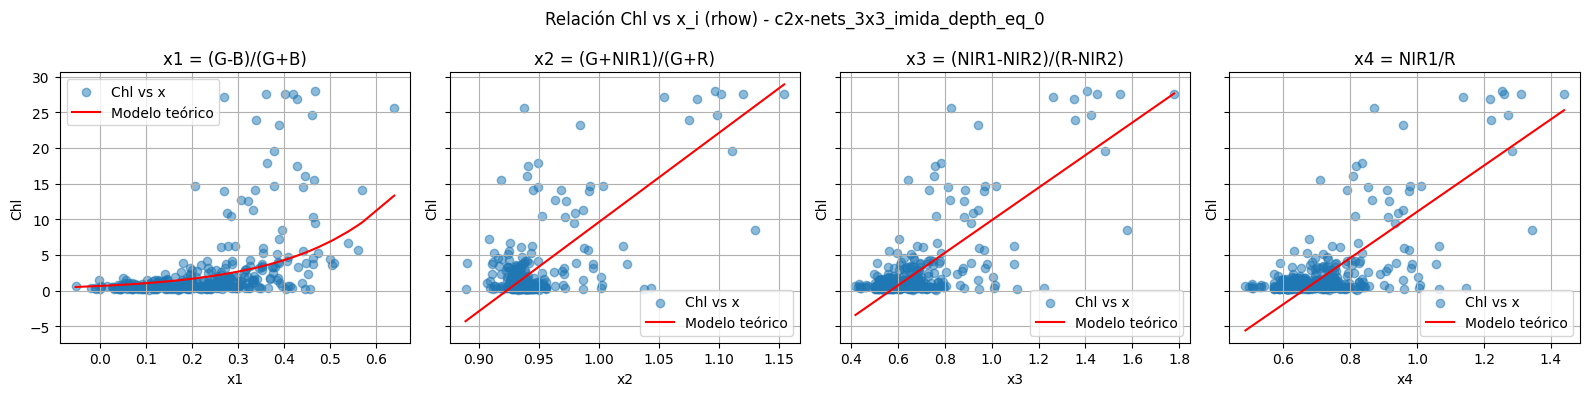

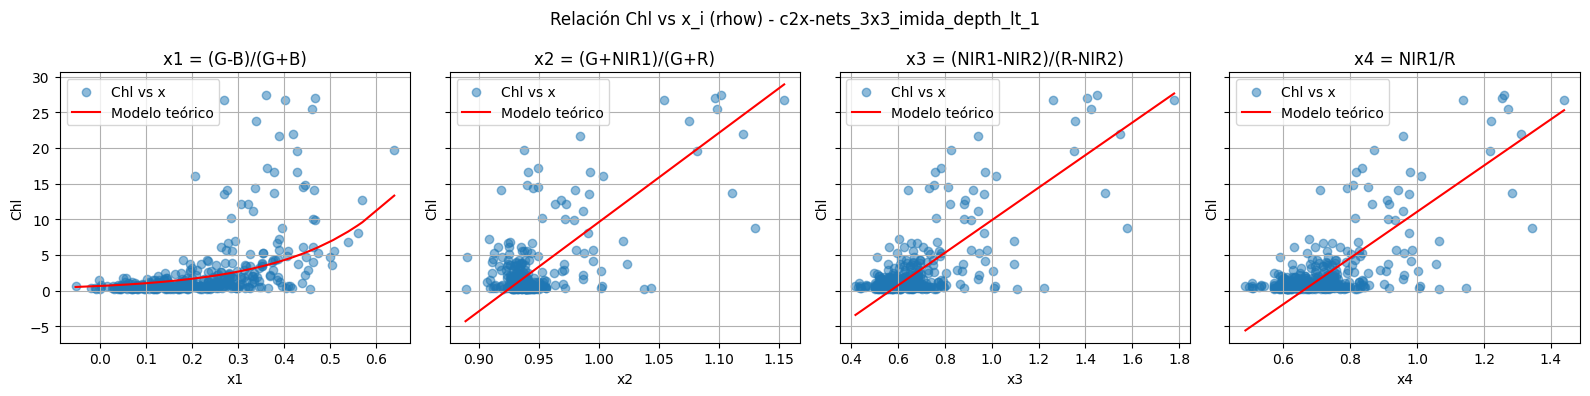

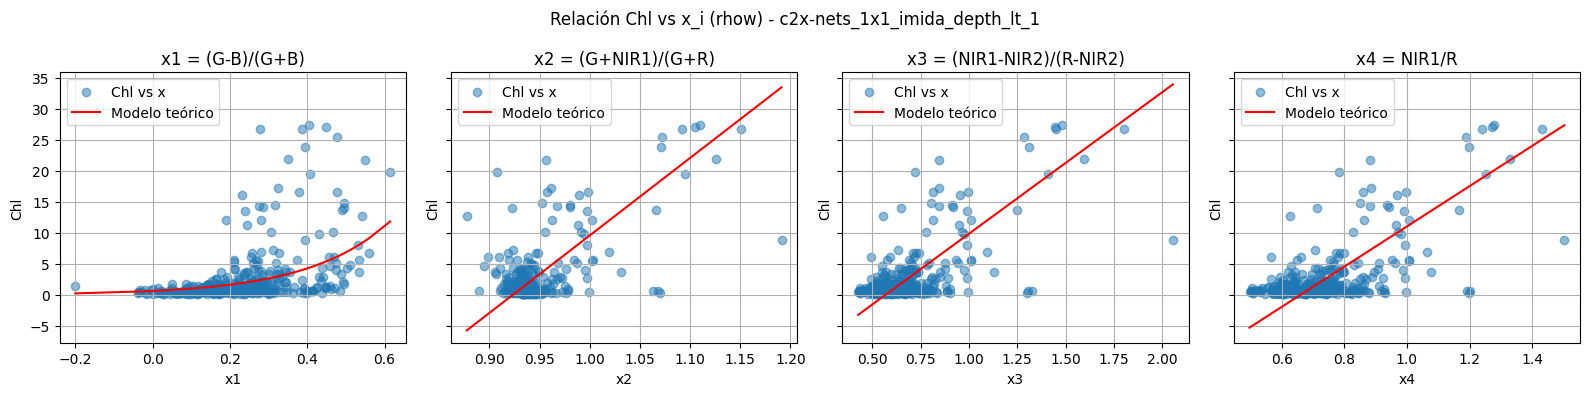

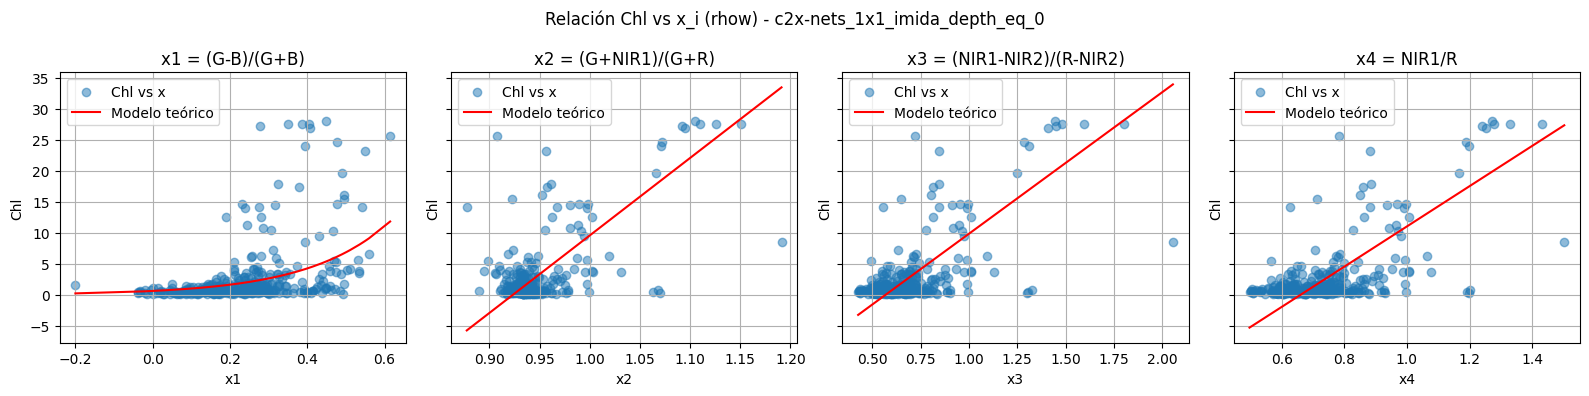

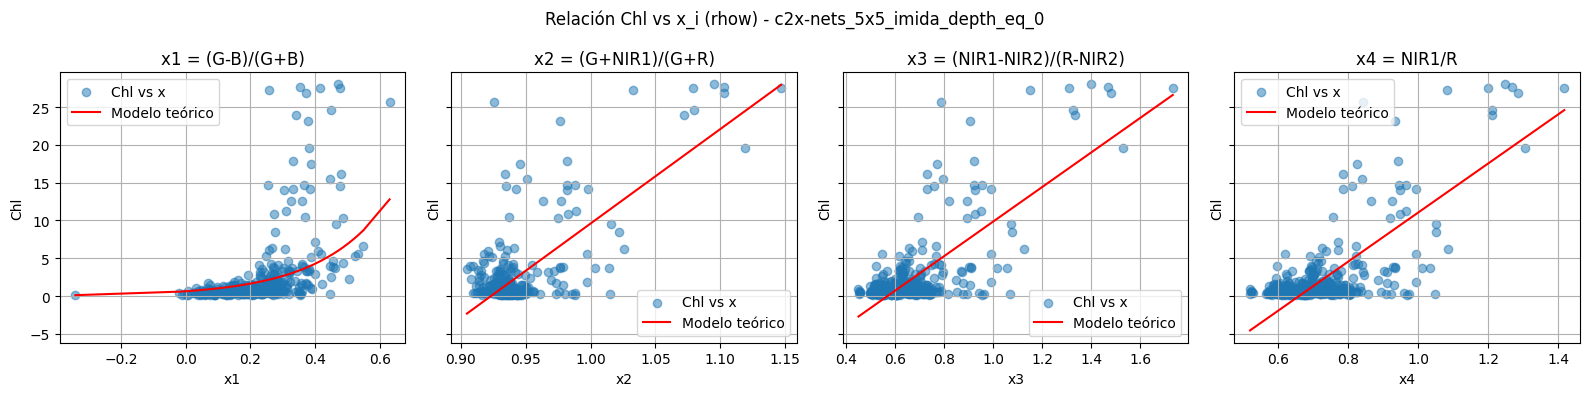

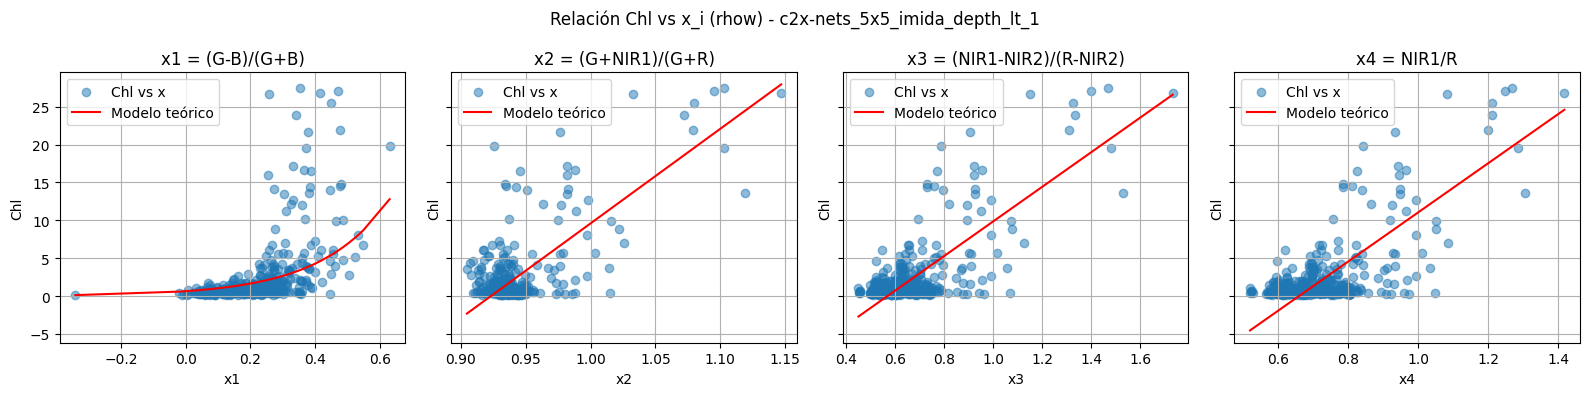

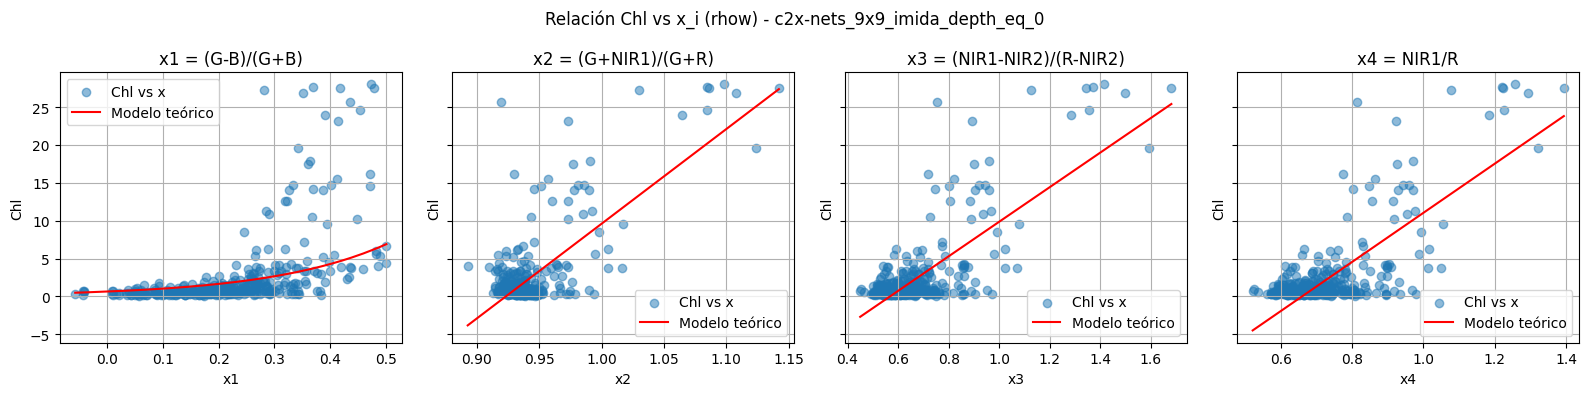

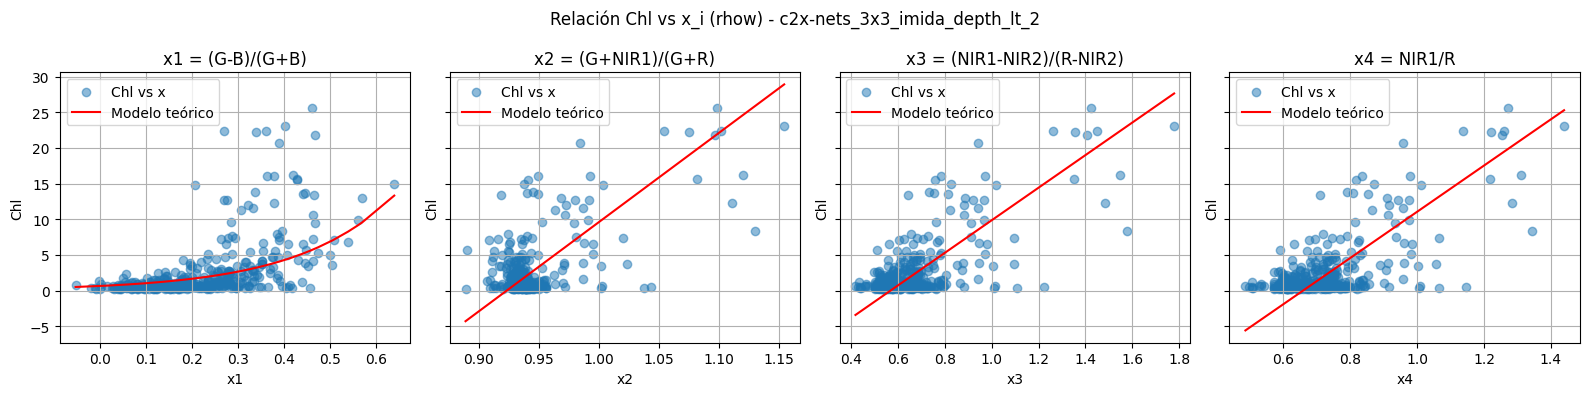

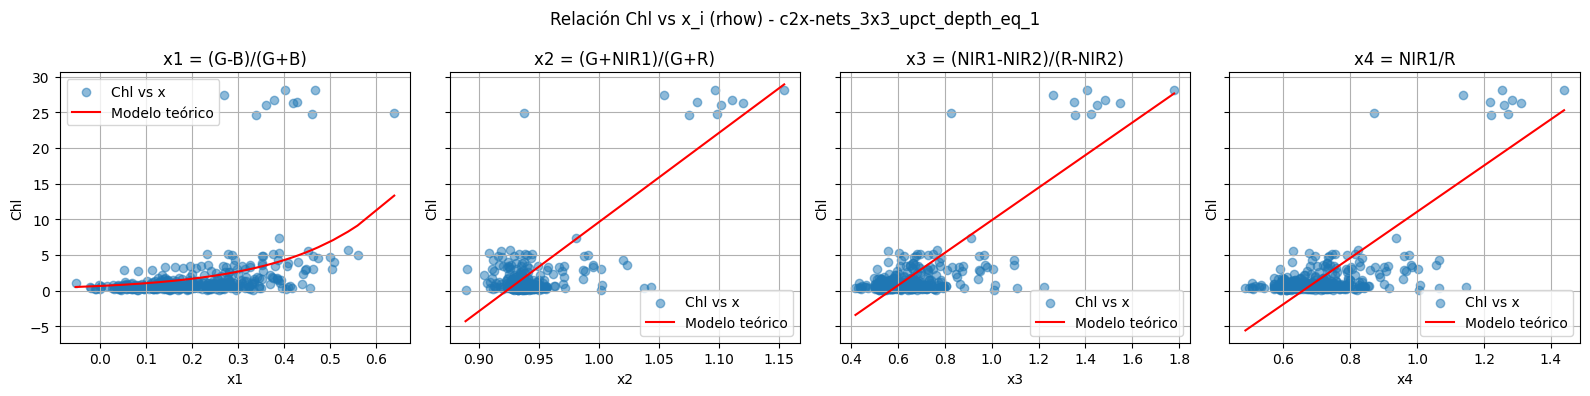

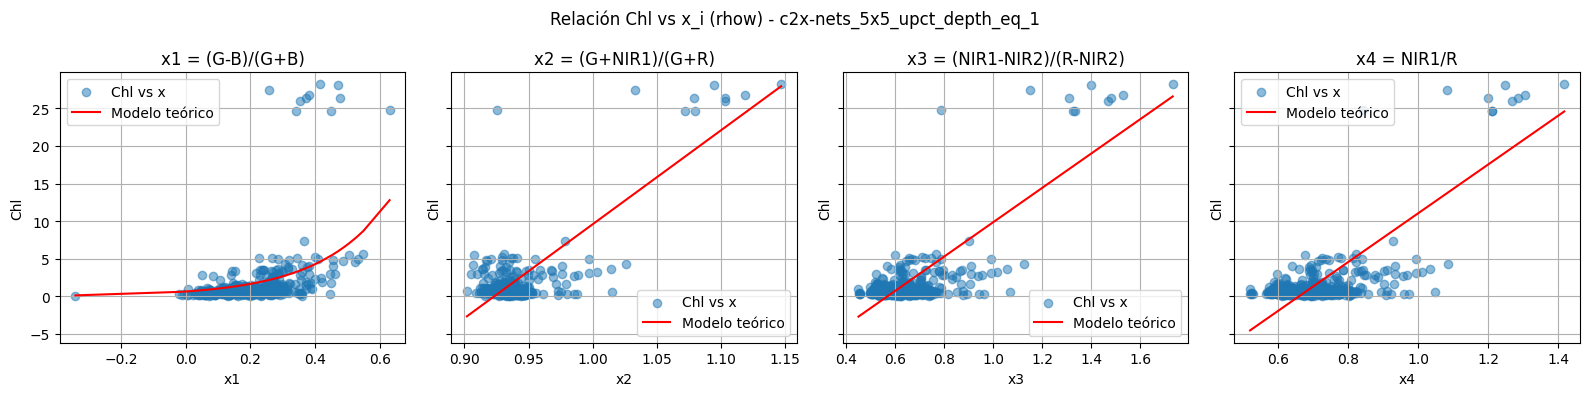

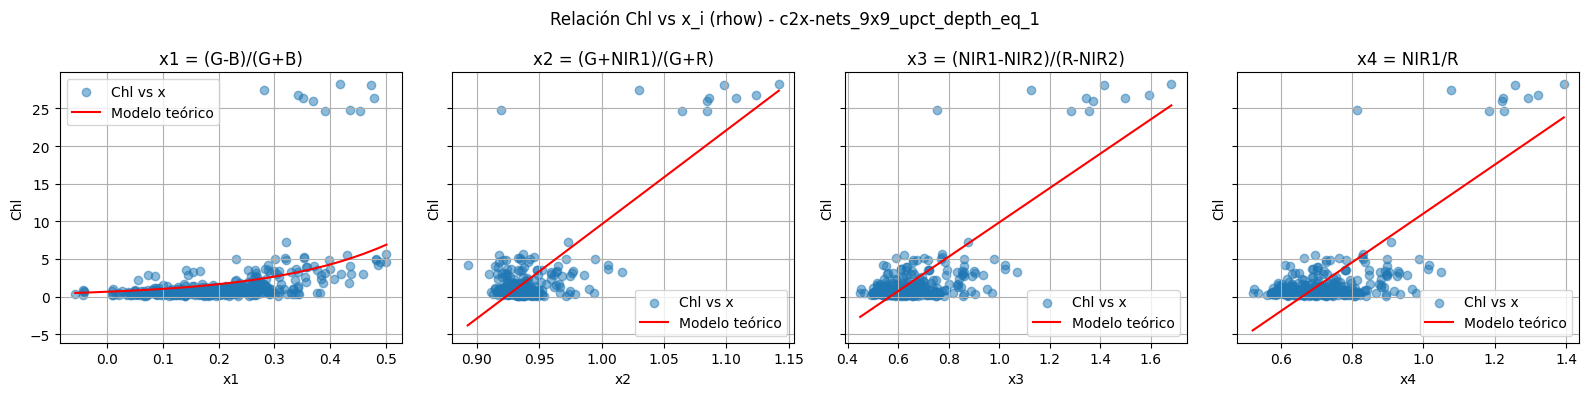

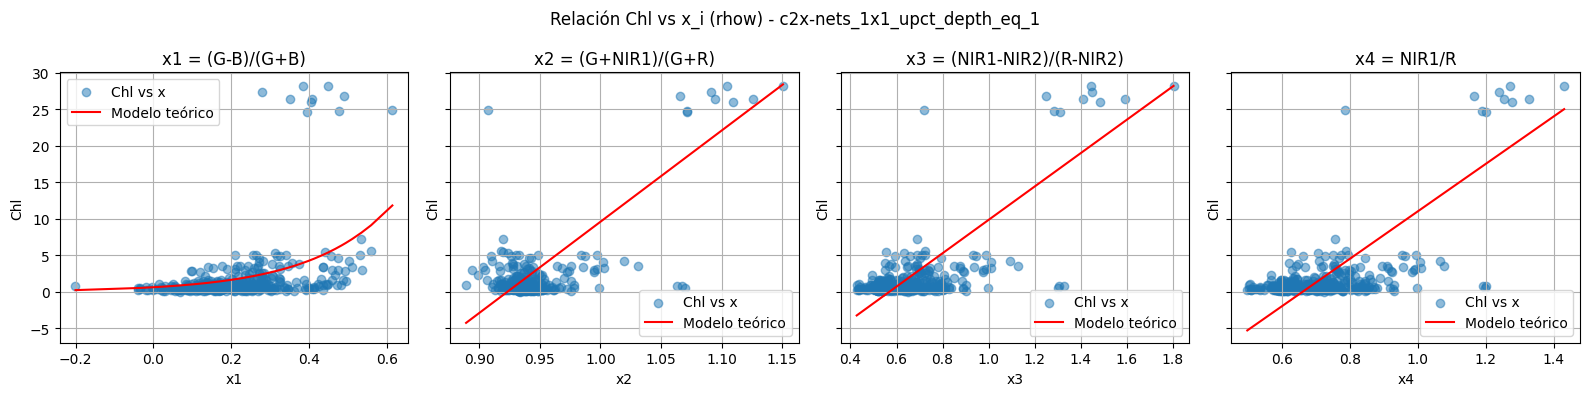

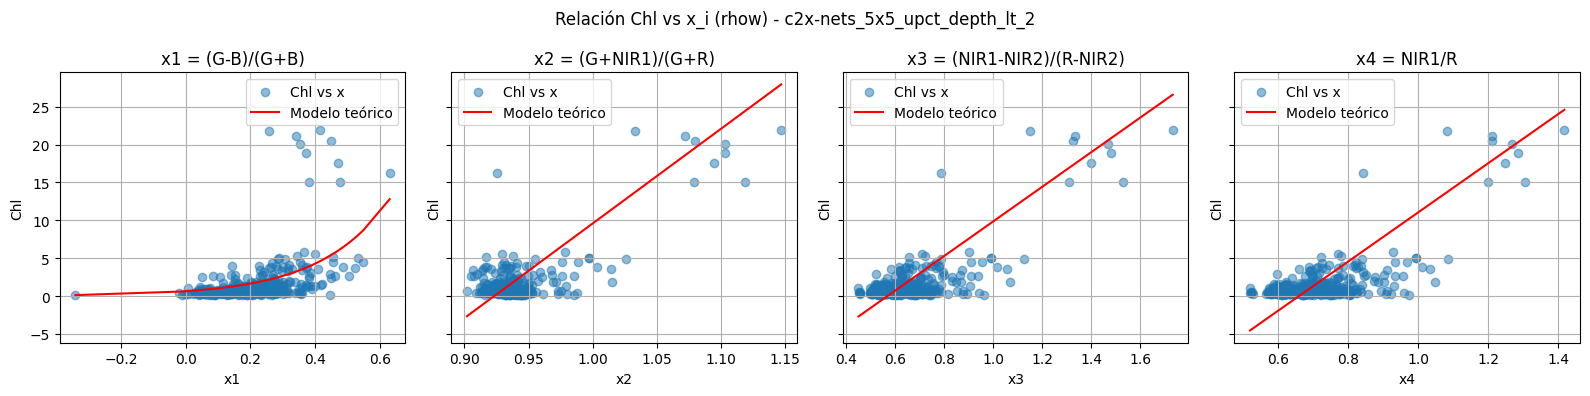

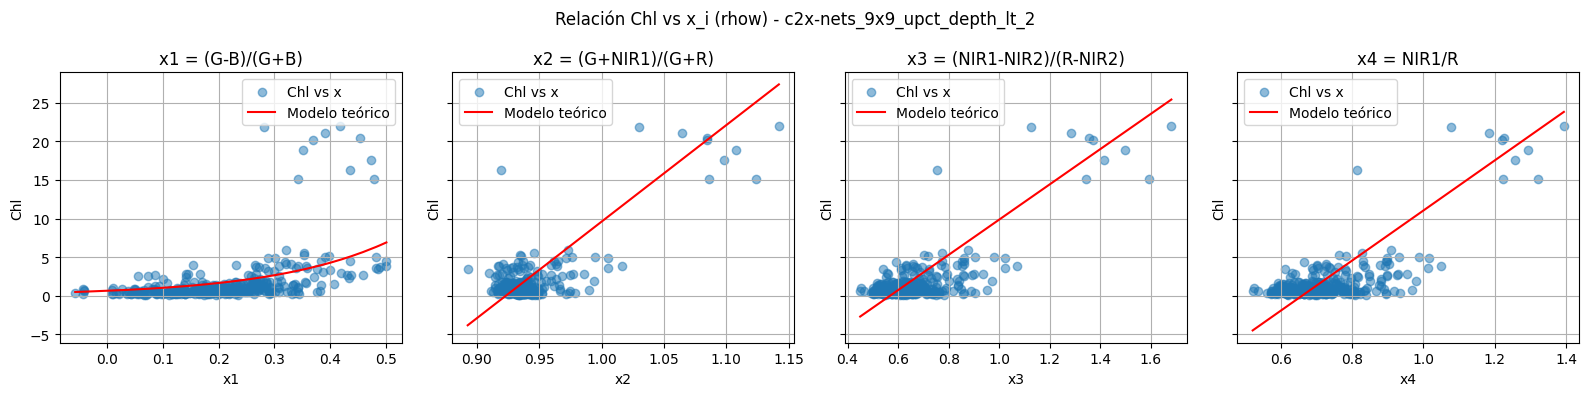

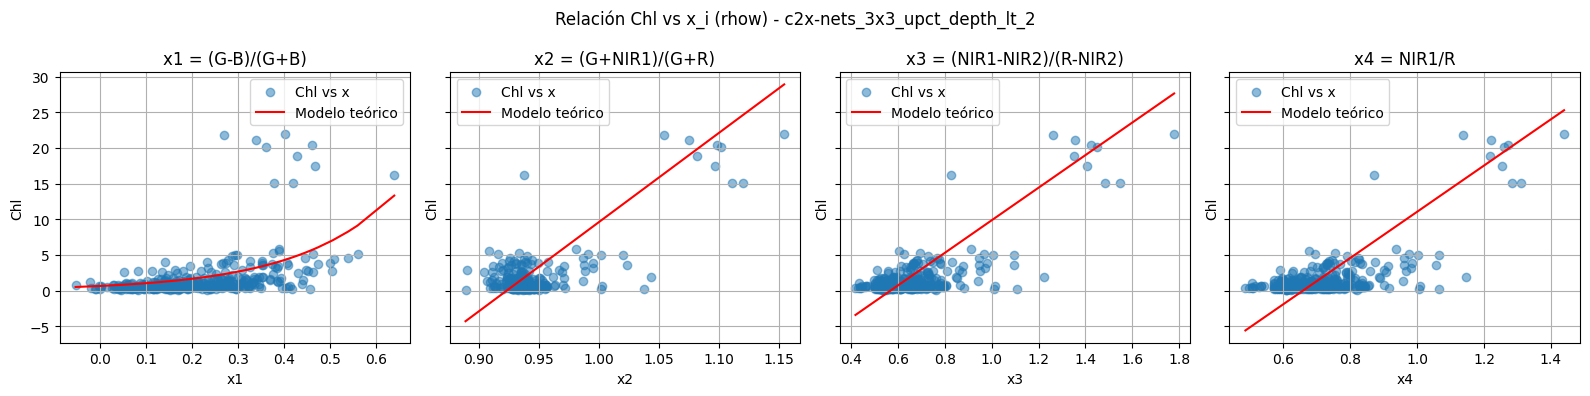

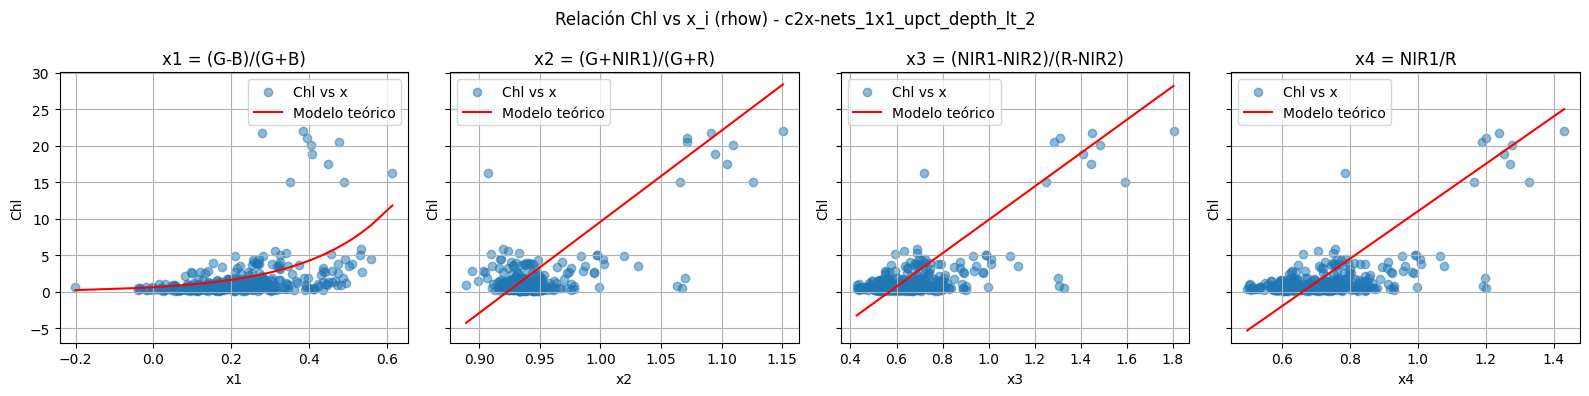

In [59]:
nombres_a_graficar = metrics_df.index
for nombre_df in nombres_a_graficar:
    if nombre_df in dfs:
        df = dfs[nombre_df]
        columnas_necesarias = ["Chl", "rhow_B2", "rhow_B3", "rhow_B4", "rhow_B5", "rhow_B6"]
        if all(col in df.columns for col in columnas_necesarias):
            #plt.savefig("saved_files/ScatterWithDate.png")
            plot_chl_vs_x_rhow(df, nombre_df)

